# Learning to stabilize a linear system

For this example we demonstrate learning to stabilize a double integrator system using [Differentiable predictive control (DPC) method](https://www.sciencedirect.com/science/article/pii/S0959152422000981). 

**Differentiable Predictive Control method**:  
The DPC is a model-based policy optimization algorithm, that exploits the differentiability of a wide class of model representations for dynamical systems, including differential equations, state-space models, or various neural network architectures. In DPC, we construct a differentiable closed-loop system composed of neural control policy and system dynamics model that is to be optimized using parametric control objectives as intrinsic reward signals evaluated over a sampled distribution of the problem parameters.

<img src="./figs/DPC_simple_method.png" width="600">  

## NeuroMANCER and Dependencies

### Install (Colab only)
Skip this step when running locally.

In [1]:
!pip install neuromancer

In [2]:
!pip install eclipse-nn

*Note: When running on Colab, one might encounter a pip dependency error with Lida 0.0.10. This can be ignored*

In [3]:
import torch
from neuromancer.system import Node, System
from neuromancer.modules import blocks
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.trainer import Trainer
from neuromancer.plot import pltCL, pltPhase


In [4]:
import random
import numpy as np
import torch

# Python built-in random
random.seed(42)

# NumPy
np.random.seed(42)

# PyTorch (CPU and GPU)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)   # if using multi-GPU

# Make cuDNN deterministic (slower, but reproducible)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [5]:
# --- Bootstrap for eclipse-nn 0.1.0 bad imports (no source edits) ---
import sys, types, importlib

# Load the real package
eclipse_nn = importlib.import_module("eclipse_nn")

# Create a package-like dummy top-level module "src"
src = types.ModuleType("src")
src.__path__ = []                      # make it behave like a package
sys.modules["src"] = src               # register "src"

# Point "src.eclipse_nn" to the real eclipse_nn package
sys.modules["src.eclipse_nn"] = eclipse_nn

# (Optional but safer) pre-register the specific submodules it imports
for name in ["extract_model_info", "eclipsE", "eclipsE_fast"]:
    try:
        mod = importlib.import_module(f"eclipse_nn.{name}")
        sys.modules[f"src.eclipse_nn.{name}"] = mod
    except Exception:
        pass
# --------------------------------------------------------------------

from eclipse_nn.LipConstEstimator import LipConstEstimator


# Node and System classes

The Node class is a simple wrapper for any callable pytorch function or nn.Module which provides names for the inputs and outputs to be used in composition of a potentially cyclic computational graph.  

In [6]:
# Double integrator parameters
nx = 2
nu = 1
A = torch.tensor([[1.2, 1.0],
                  [0.0, 1.0]])
B = torch.tensor([[1.0],
                  [0.5]])

# linear state space model
xnext = lambda x, u: x @ A.T + u @ B.T    
double_integrator = Node(xnext, ['X', 'U'], ['X'], name='integrator')

# neural control policy
mlp = blocks.MLP(nx, nu, bias=True,
                 linear_map=torch.nn.Linear,
                 nonlin=torch.nn.ReLU,
                 hsizes=[20, 20, 20, 20])
policy = Node(mlp, ['X'], ['U'], name='policy')

# closed loop system definition
cl_system = System([policy, double_integrator])
# cl_system.show()

penalize the jacobian of the closed-loop system. so NO \|\|A+BK\|\|_2 <= 1.    u = NN(x). \|\|NN(x)\|\|<=K\|\|x\|\|. 

# Training dataset generation

For a training dataset we randomly sample points away from the origin of the 2D space the system operates in. 

In [7]:
# Training dataset generation
train_data = DictDataset({'X': 3.*torch.randn(3333, 1, nx)}, name='train')  # Split conditions into train and dev
dev_data = DictDataset({'X': 3.*torch.randn(3333, 1, nx)}, name='dev')
train_loader = torch.utils.data.DataLoader(train_data, batch_size=3333,
                                           collate_fn=train_data.collate_fn, shuffle=False)
dev_loader = torch.utils.data.DataLoader(dev_data, batch_size=3333,
                                         collate_fn=dev_data.collate_fn, shuffle=False)

# Optimization problem

We want to learn a controller that stabilizes the double integrator system. In other words we would like a control policy that pushes the system to stay at the origin. 

In [8]:
# Define optimization problem
u = variable('U')
x = variable('X')
action_loss = 0.0001 * (u == 0.)^2  # control penalty
regulation_loss = 10. * (x == 0.)^2  # target position
loss = PenaltyLoss([action_loss, regulation_loss], [])
problem = Problem([cl_system], loss)
optimizer = torch.optim.AdamW(policy.parameters(), lr=0.001)

# Optimize problem with a system rollout of 2 time steps


In [9]:
trainer = Trainer(
    problem,
    train_loader,
    dev_loader,
    dev_loader,
    optimizer=optimizer,
    epochs=400,
    train_metric="train_loss",
    dev_metric="dev_loss",
    eval_metric='dev_loss',
    warmup=400,
)

# Train model with prediction horizon of 2
cl_system.nsteps = 2
best_model = trainer.train()

C:\Users\22384\anaconda3\envs\dpc\Lib\site-packages\neuromancer\constraint.py:172: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([3333, 2, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(left, right)
C:\Users\22384\anaconda3\envs\dpc\Lib\site-packages\neuromancer\constraint.py:172: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([3333, 3, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(left, right)


epoch: 0  train_loss: 193.7262725830078
epoch: 1  train_loss: 193.29698181152344
epoch: 2  train_loss: 192.85317993164062
epoch: 3  train_loss: 192.39498901367188
epoch: 4  train_loss: 191.9197998046875
epoch: 5  train_loss: 191.42550659179688
epoch: 6  train_loss: 190.91217041015625
epoch: 7  train_loss: 190.38552856445312
epoch: 8  train_loss: 189.84490966796875
epoch: 9  train_loss: 189.28817749023438
epoch: 10  train_loss: 188.7124481201172
epoch: 11  train_loss: 188.1131134033203
epoch: 12  train_loss: 187.48597717285156
epoch: 13  train_loss: 186.82762145996094
epoch: 14  train_loss: 186.13705444335938
epoch: 15  train_loss: 185.41360473632812
epoch: 16  train_loss: 184.66006469726562
epoch: 17  train_loss: 183.87600708007812
epoch: 18  train_loss: 183.05755615234375
epoch: 19  train_loss: 182.19473266601562
epoch: 20  train_loss: 181.28033447265625
epoch: 21  train_loss: 180.311279296875
epoch: 22  train_loss: 179.27865600585938
epoch: 23  train_loss: 178.17324829101562
epoch: 2

# Evaluate best model on a system rollout 

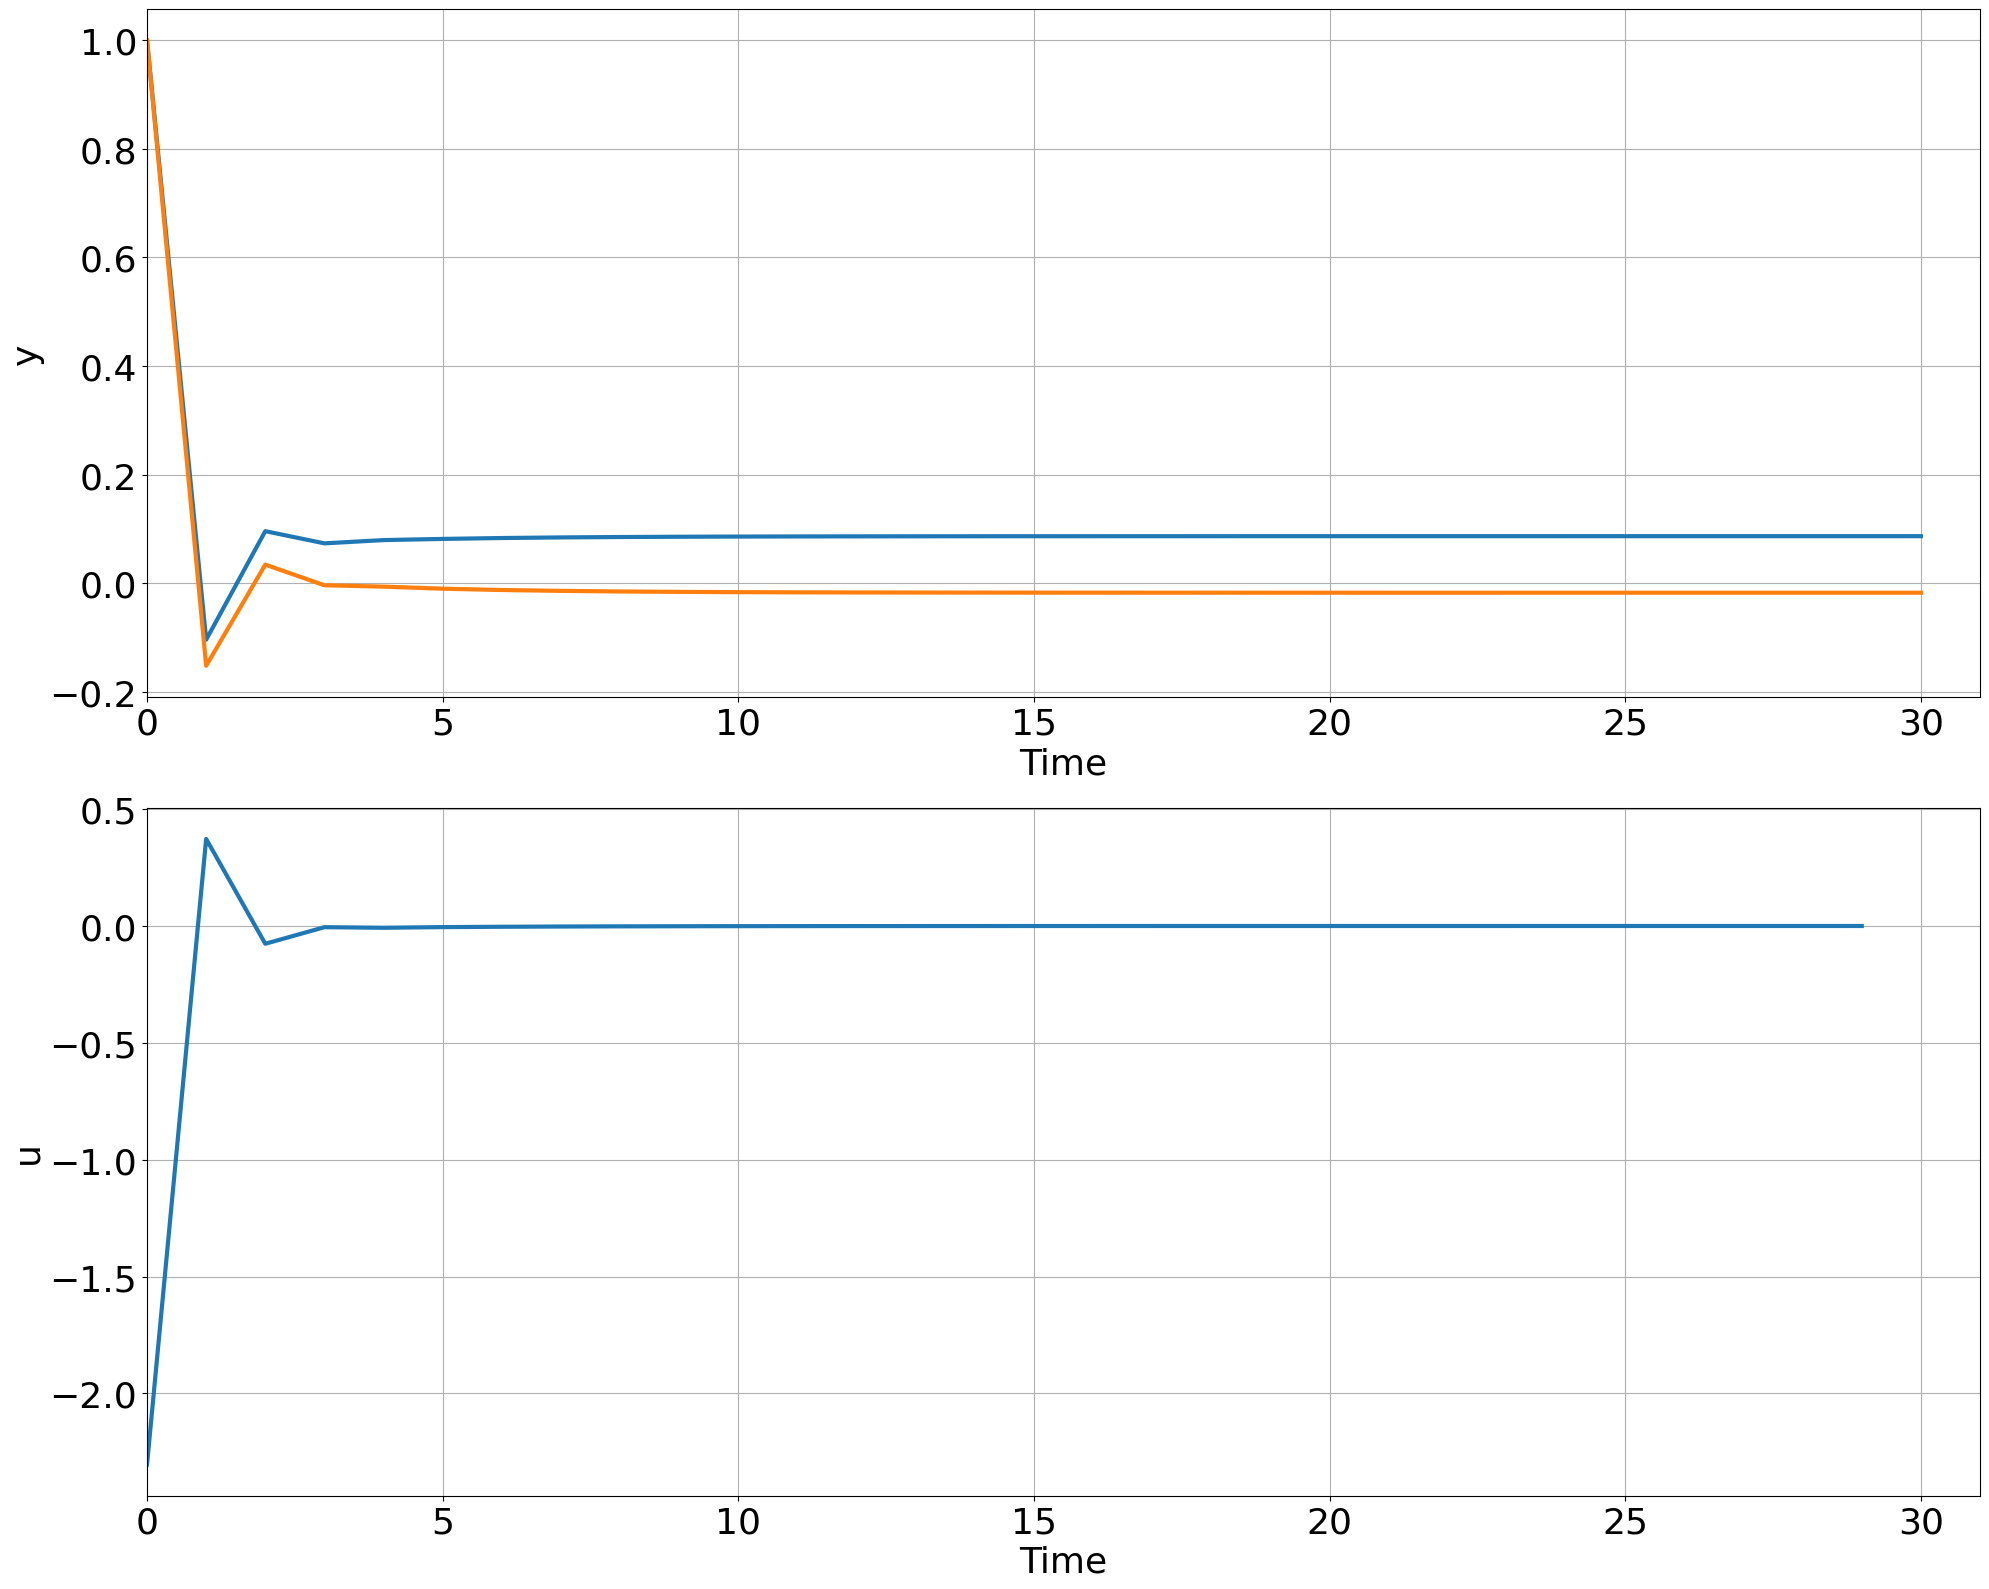

<Figure size 640x480 with 0 Axes>

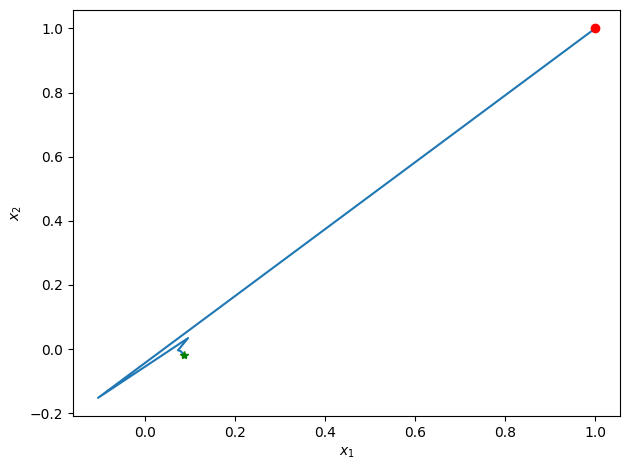

<Figure size 640x480 with 0 Axes>

In [10]:
# Test best model with prediction horizon of 50
problem.load_state_dict(best_model)
data = {'X': torch.ones(1, 1, nx, dtype=torch.float32)}
nsteps = 30
cl_system.nsteps = nsteps
trajectories = cl_system(data)
pltCL(Y=trajectories['X'].detach().reshape(nsteps+1, 2), U=trajectories['U'].detach().reshape(nsteps, 1), figname='cl.png')
pltPhase(X=trajectories['X'].detach().reshape(nsteps+1, 2), figname='phase.png')

# Train with Regularization (xyz)

In [11]:
# Double integrator parameters
nx = 2
nu = 1
A = torch.tensor([[1.2, 1.0],
                  [0.0, 1.0]])
B = torch.tensor([[1.0],
                  [0.5]])

# linear state space model
xnext = lambda x, u: x @ A.T + u @ B.T    
double_integrator = Node(xnext, ['X', 'U'], ['X'], name='integrator')

# neural control policy
mlp_reg = blocks.MLP(nx, nu, bias=True,
                 linear_map=torch.nn.Linear,
                 nonlin=torch.nn.ReLU,
                 hsizes=[20, 20, 20, 20])
policy_reg = Node(mlp_reg, ['X'], ['U'], name='policy')

# Training dataset generation
train_data = DictDataset({'X': 3.*torch.randn(3333, 1, nx)}, name='train')  # Split conditions into train and dev
dev_data = DictDataset({'X': 3.*torch.randn(3333, 1, nx)}, name='dev')
train_loader = torch.utils.data.DataLoader(train_data, batch_size=3333,
                                           collate_fn=train_data.collate_fn, shuffle=False)
dev_loader = torch.utils.data.DataLoader(dev_data, batch_size=3333,
                                         collate_fn=dev_data.collate_fn, shuffle=False)

## Penalize on the Jacobian of Policy u=NN(x)

In [12]:
import torch
import torch.nn as nn

'''
def _jac_fro_node(X):
    # X comes in as [B, nx] (System slices the time axis for you).
    with torch.enable_grad():
        X = X.detach().requires_grad_(True)          # leaf with grad
        U = mlp_reg(X)                                # [B, nu]
        if U.dim() == 1:
            U = U.unsqueeze(-1)

        sqsum = 0.0
        for j in range(U.shape[1]):
            g = torch.autograd.grad(
                U[:, j].sum(), X,
                create_graph=True, retain_graph=True
            )[0]                                      # [B, nx]
            sqsum = sqsum + (g * g).sum(dim=1)        # [B]

        Jfro = torch.sqrt(sqsum + 1e-12).unsqueeze(-1)  # [B, 1]
    return Jfro
'''


'\ndef _jac_fro_node(X):\n    # X comes in as [B, nx] (System slices the time axis for you).\n    with torch.enable_grad():\n        X = X.detach().requires_grad_(True)          # leaf with grad\n        U = mlp_reg(X)                                # [B, nu]\n        if U.dim() == 1:\n            U = U.unsqueeze(-1)\n\n        sqsum = 0.0\n        for j in range(U.shape[1]):\n            g = torch.autograd.grad(\n                U[:, j].sum(), X,\n                create_graph=True, retain_graph=True\n            )[0]                                      # [B, nx]\n            sqsum = sqsum + (g * g).sum(dim=1)        # [B]\n\n        Jfro = torch.sqrt(sqsum + 1e-12).unsqueeze(-1)  # [B, 1]\n    return Jfro\n'

In [13]:
'''
jac_fro = Node(_jac_fro_node, ['X'], ['Jfro'], name='jac_fro')

# closed loop system definition (add the jac_fro node)
cl_system_reg = System([policy_reg, double_integrator, jac_fro])

# variables
u = variable('U')
x = variable('X')
j = variable('Jfro')   # from the Jacobian-Fro node
'''

"\njac_fro = Node(_jac_fro_node, ['X'], ['Jfro'], name='jac_fro')\n\n# closed loop system definition (add the jac_fro node)\ncl_system_reg = System([policy_reg, double_integrator, jac_fro])\n\n# variables\nu = variable('U')\nx = variable('X')\nj = variable('Jfro')   # from the Jacobian-Fro node\n"

## Penalize on the Jacobian (Frobenius-norm / $l_2$ norm) of the Closed-loop System (Expensive)

In [14]:
def make_jac_cl_node(policy_node):
    """Node: inputs ['X'] (batch,nx) -> outputs ['Jcl'] (batch,1) with ||A + B J_pi||_F^2."""
    policy_module = policy_node.callable  # underlying nn.Module: X -> U

    def _forward(X):                      # <-- NOTE: positional tensor, not dict
        X = X.requires_grad_(True)

        Bsize = X.shape[0]
        vals = []
        for b in range(Bsize):
            xb = X[b]                    # (nx,)

            def f_single(x_single):      # R^nx -> R^nu
                return policy_module(x_single.unsqueeze(0)).squeeze(0)

            J_pi = torch.autograd.functional.jacobian(f_single, xb, create_graph=True)  # (nu,nx)
            J_cl = A + B @ J_pi                                                          # (nx,nx)
            # vals.append(torch.linalg.norm(J_cl, ord='fro')**2)                           # scalar
            vals.append(torch.linalg.norm(J_cl, ord=2)**2) 

        Jcl = torch.stack(vals, dim=0).unsqueeze(1)  # (batch,1)
        return Jcl                                   # <-- return a tensor, not dict

    return Node(_forward, ['X'], ['Jcl'], name='jac_cl')

In [15]:
jac_cl = make_jac_cl_node(policy_reg)    
cl_system_reg = System(nodes=[policy_reg, double_integrator, jac_cl])

u = variable('U')
x = variable('X')
jcl = variable("Jcl")



In [16]:
# objectives: minimize squared norms directly (no == 0.)
action_loss     =  0.0001 * (u == 0.)^2       
regulation_loss = 10. * (x == 0.)^2     
# jac_fro_loss    = 1 * (j == 0.)^2     # 1e-3 
jac_cl_loss    = 5 * (jcl == 0.)^2     # 1e-3 

#loss_reg = PenaltyLoss([action_loss, regulation_loss,jac_fro_loss], [])
loss_reg = PenaltyLoss([action_loss, regulation_loss,jac_cl_loss], [])
problem_reg = Problem([cl_system_reg], loss_reg)



In [17]:
optimizer = torch.optim.AdamW(policy_reg.parameters(), lr=0.003)

trainer_reg = Trainer(
    problem_reg,
    train_loader,
    dev_loader,
    dev_loader,
    optimizer=optimizer,
    epochs=100,
    train_metric="train_loss",
    dev_metric="dev_loss",
    eval_metric='dev_loss',
    warmup=400,
)


In [18]:
# Train model with prediction horizon of 2
cl_system_reg.nsteps = 2
best_model_reg = trainer_reg.train()

epoch: 0  train_loss: 244.12083435058594
epoch: 1  train_loss: 242.68118286132812
epoch: 2  train_loss: 241.00604248046875
epoch: 3  train_loss: 239.034912109375
epoch: 4  train_loss: 236.74676513671875
epoch: 5  train_loss: 234.149658203125
epoch: 6  train_loss: 231.205810546875
epoch: 7  train_loss: 227.897705078125
epoch: 8  train_loss: 224.1870574951172
epoch: 9  train_loss: 220.0493927001953
epoch: 10  train_loss: 215.4872589111328
epoch: 11  train_loss: 210.49815368652344
epoch: 12  train_loss: 205.05784606933594
epoch: 13  train_loss: 199.2042236328125
epoch: 14  train_loss: 192.91502380371094
epoch: 15  train_loss: 186.25790405273438
epoch: 16  train_loss: 179.2631072998047
epoch: 17  train_loss: 172.02011108398438
epoch: 18  train_loss: 164.5866241455078
epoch: 19  train_loss: 157.0540008544922
epoch: 20  train_loss: 149.59152221679688
epoch: 21  train_loss: 142.3128204345703
epoch: 22  train_loss: 135.3458251953125
epoch: 23  train_loss: 128.72802734375
epoch: 24  train_loss:

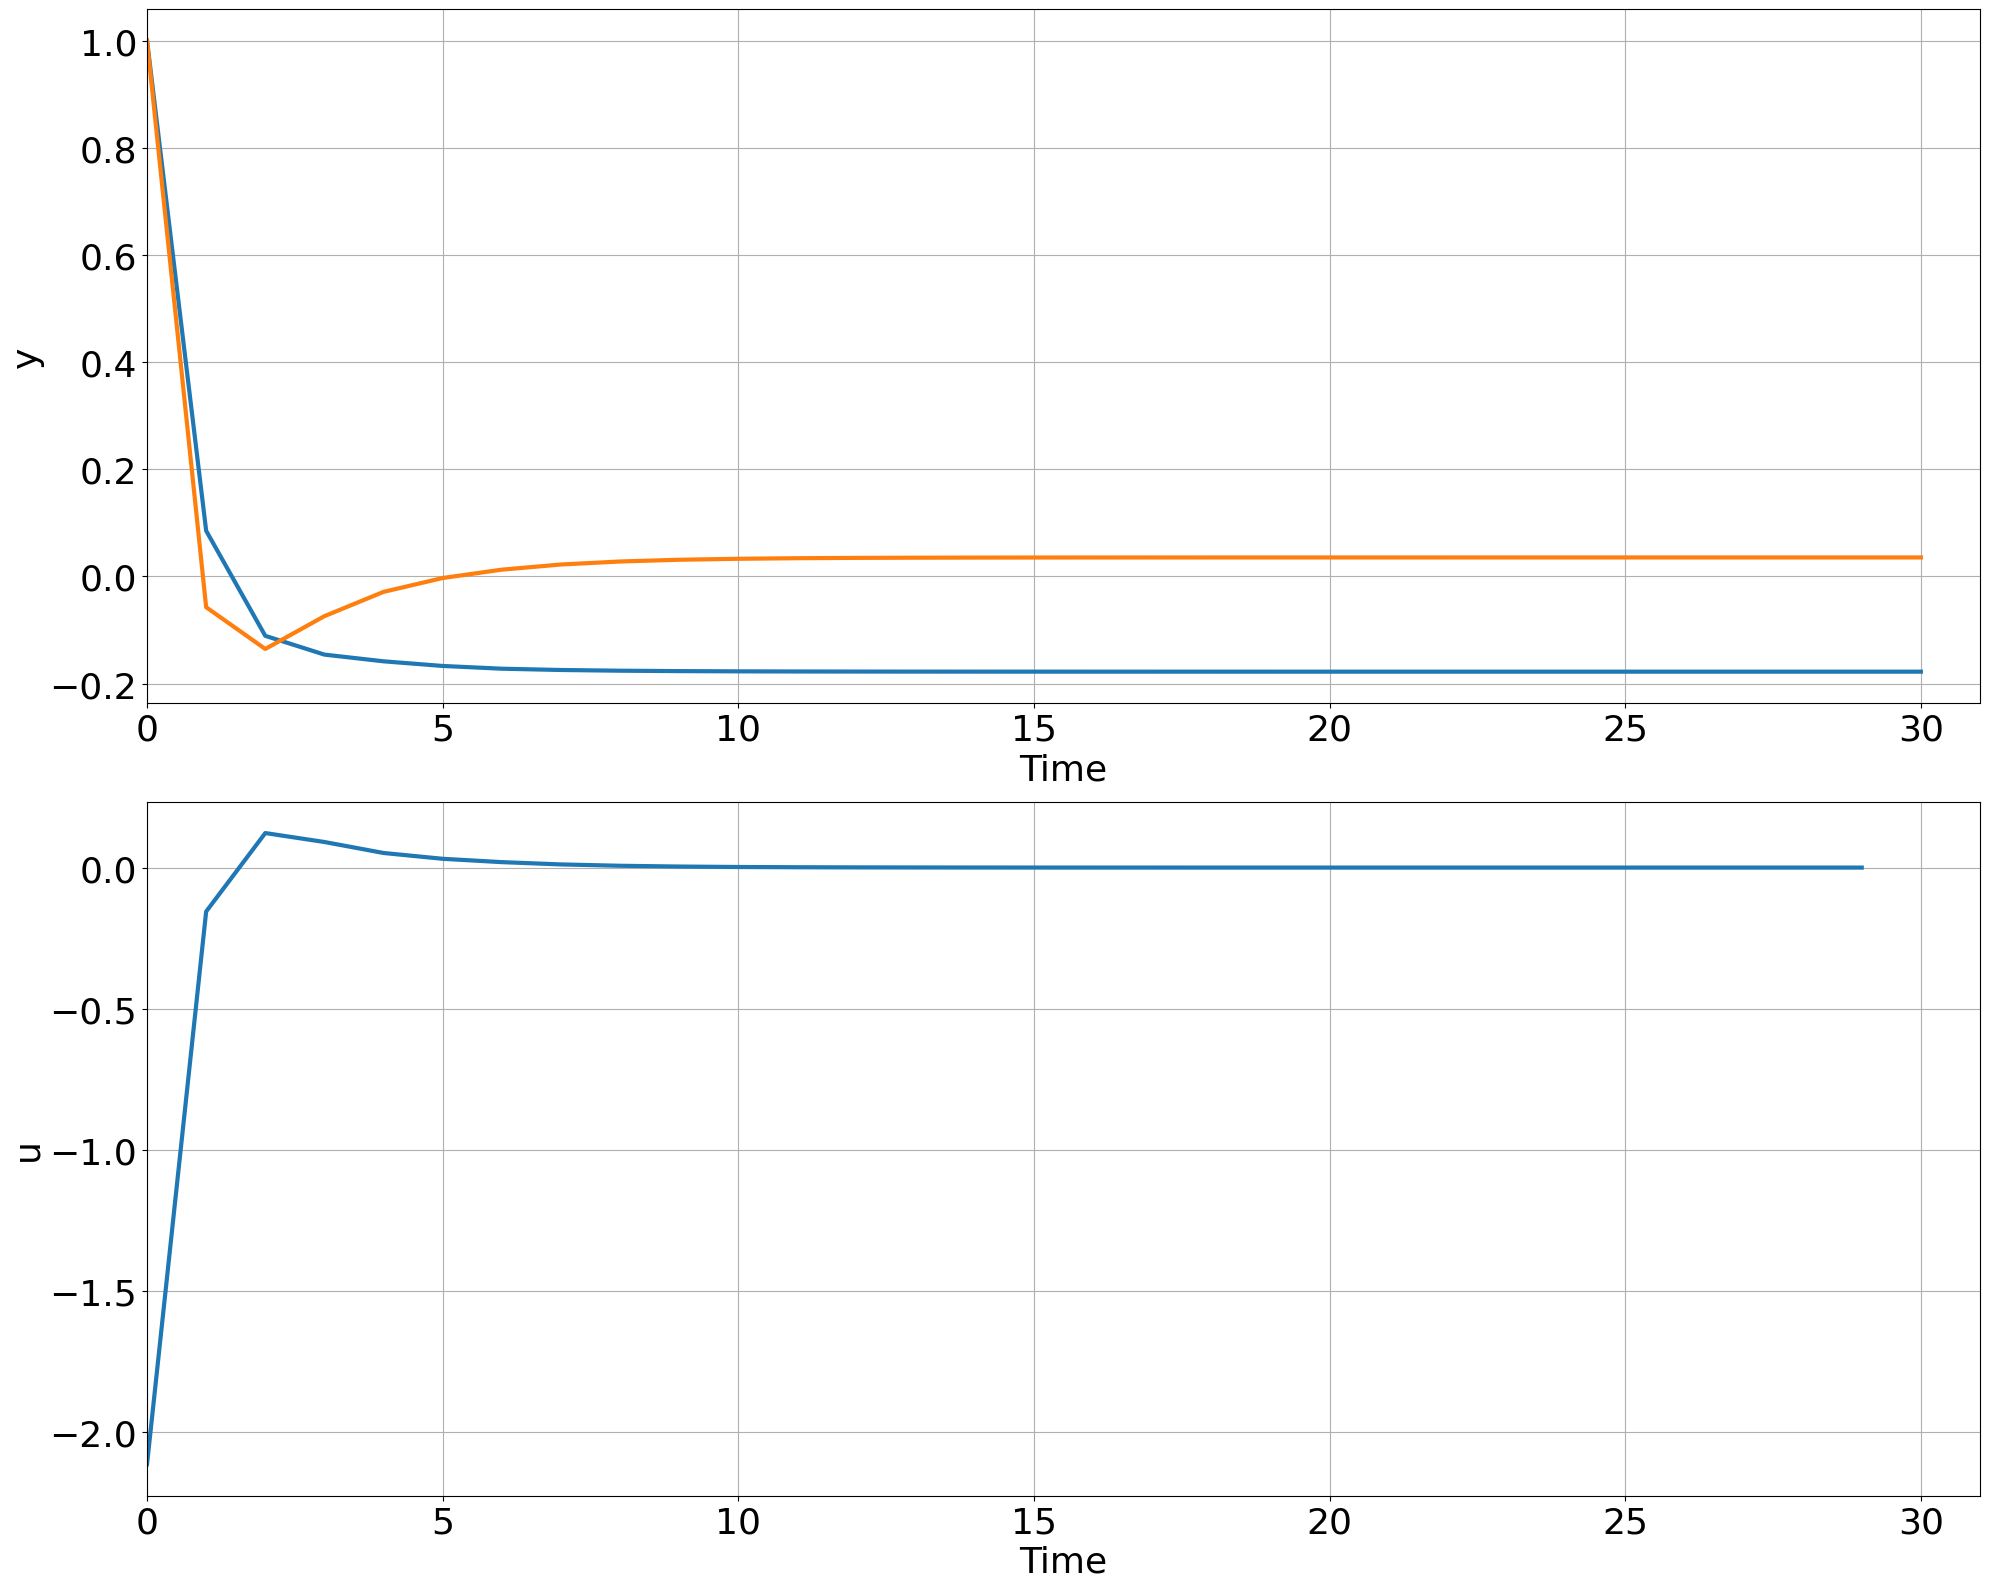

<Figure size 640x480 with 0 Axes>

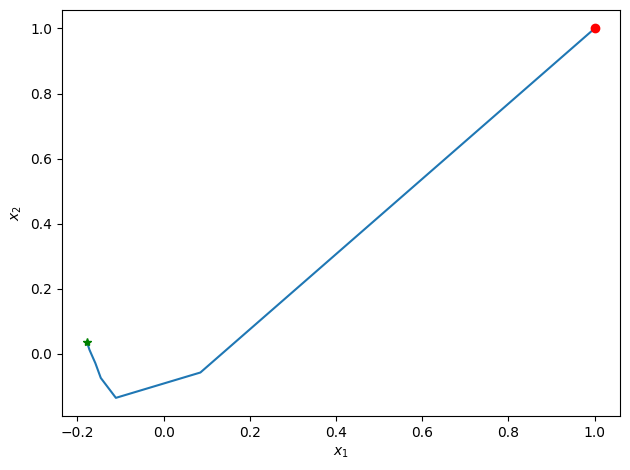

<Figure size 640x480 with 0 Axes>

In [19]:
# Test best model with prediction horizon of 50
problem_reg.load_state_dict(best_model_reg)
data = {'X': torch.ones(1, 1, nx, dtype=torch.float32)}
nsteps = 30
cl_system_reg.nsteps = nsteps
trajectories = cl_system_reg(data)
pltCL(Y=trajectories['X'].detach().reshape(nsteps+1, 2), U=trajectories['U'].detach().reshape(nsteps, 1), figname='cl.png')
pltPhase(X=trajectories['X'].detach().reshape(nsteps+1, 2), figname='phase.png')

# Robustness Testing (xyz)

In [20]:
# add a function to simulate with starting point being x0 (xyz)
def run_with_x0(x0_vec, cl_system, nsteps=30):
    """
    Run the closed-loop system from a given initial condition.
    
    x0_vec: list or array of length nx, e.g. [1.0, 1.0]
    nsteps: prediction horizon
    
    Returns:
        X: (nsteps+1, nx) array of states
        U: (nsteps, nu) array of inputs
    """
    # shape into (batch=1, time=1, nx)
    x0 = torch.tensor(x0_vec, dtype=torch.float32).view(1, 1, -1)
    data = {'X': x0}
    
    cl_system.nsteps = nsteps
    out = cl_system(data)

    X = out['X'].detach().reshape(nsteps+1, -1).cpu().numpy()
    U = out['U'].detach().reshape(nsteps, -1).cpu().numpy()
    return X, U


In [21]:
# --- run both sims ---
X11, U11 = run_with_x0([-20.0, 10.0], cl_system, nsteps=10)
X12, U12 = run_with_x0([-19.0, 12.0], cl_system, nsteps=10)

X21, U21 = run_with_x0([-20.0, 10.0], cl_system_reg, nsteps=10)
X22, U22 = run_with_x0([-19.0, 12.0], cl_system_reg, nsteps=10)

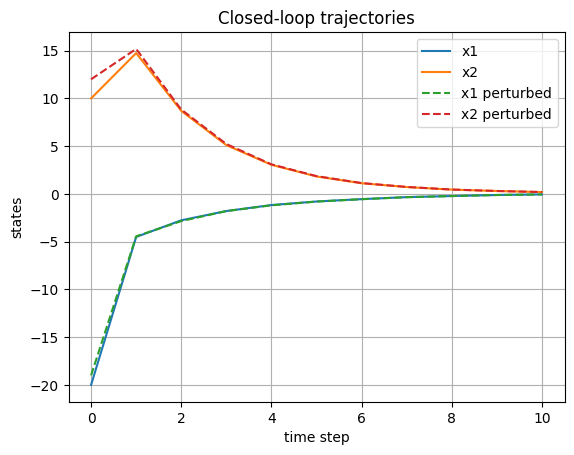

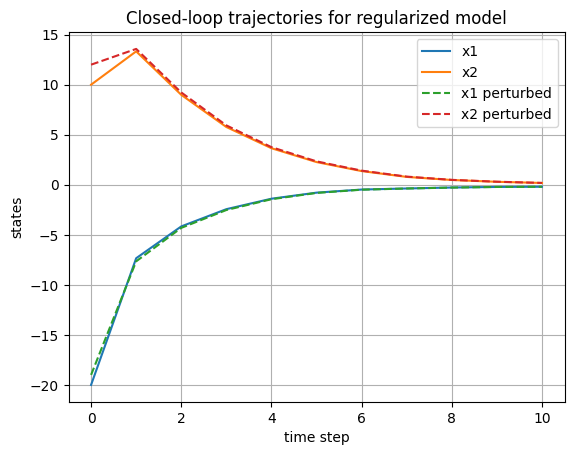

In [22]:
# plotting
import matplotlib.pyplot as plt


# --- manual CL plot with both trajectories ---
plt.figure()
plt.plot(X11[:,0], label='x1')
plt.plot(X11[:,1], label='x2')
plt.plot(X12[:,0], '--', label='x1 perturbed')
plt.plot(X12[:,1], '--', label='x2 perturbed')
plt.xlabel('time step')
plt.ylabel('states')
plt.title('Closed-loop trajectories')
plt.legend()
plt.grid(True)
# plt.savefig("cl_both.png", dpi=200)

plt.figure()
plt.plot(X21[:,0], label='x1')
plt.plot(X21[:,1], label='x2')
plt.plot(X22[:,0], '--', label='x1 perturbed')
plt.plot(X22[:,1], '--', label='x2 perturbed')
plt.xlabel('time step')
plt.ylabel('states')
plt.title('Closed-loop trajectories for regularized model')
plt.legend()
plt.grid(True)

plt.show()

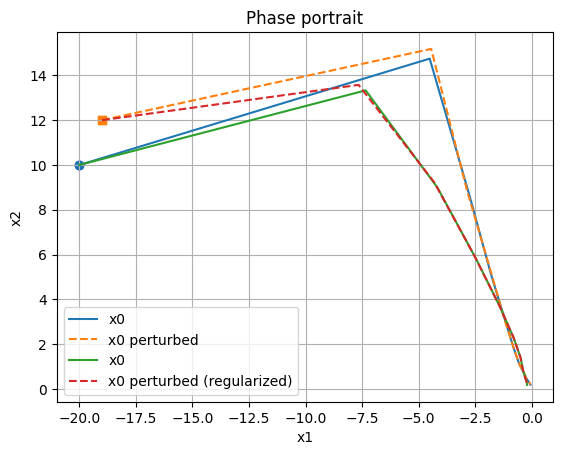

In [23]:
plt.figure()
plt.plot(X11[:,0], X11[:,1], label='x0')
plt.plot(X12[:,0], X12[:,1], '--', label='x0 perturbed')
plt.scatter(X11[0,0], X11[0,1], marker='o', c='blue')
plt.scatter(X12[0,0], X12[0,1], marker='s', c='orange')

plt.plot(X21[:,0], X21[:,1], label='x0')
plt.plot(X22[:,0], X22[:,1], '--', label='x0 perturbed (regularized)')
plt.scatter(X21[0,0], X21[0,1], marker='o')
plt.scatter(X22[0,0], X22[0,1], marker='s')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Phase portrait')
plt.legend()
plt.grid(True)
plt.savefig("phase_both.png", dpi=200)

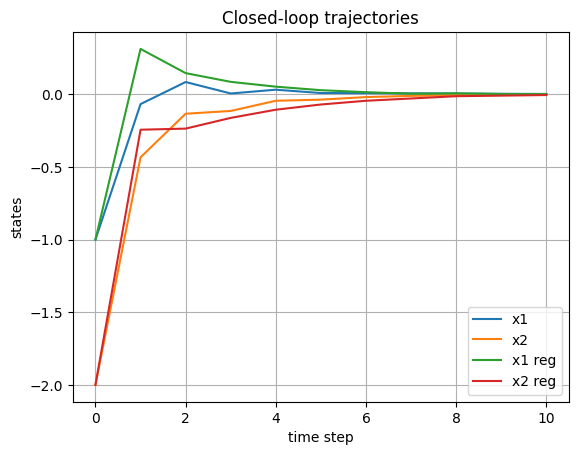

In [24]:
plt.figure()
plt.plot(X11[:,0]-X12[:,0], label='x1')
plt.plot(X11[:,1]-X12[:,1], label='x2')
#plt.plot(X12[:,0], '--', label='x1 perturbed')
#plt.plot(X12[:,1], '--', label='x2 perturbed')
plt.plot(X21[:,0]-X22[:,0], label='x1 reg')
plt.plot(X21[:,1]-X22[:,1], label='x2 reg')
plt.xlabel('time step')
plt.ylabel('states')
plt.title('Closed-loop trajectories')
plt.legend()
plt.grid(True)

### closer to nominal trjactory and always smoother?

# Estimate Lipschitz constant for NN (u=NN(x))

In [25]:
import torch.nn as nn
def extract_model_info(model):
    """
    Given a PyTorch model, returns:
    - weights: list of weight tensors
    - sizes: list of weight shapes
    - activations: list of activation function names (or None)
    - num_layers: number of parameterized layers
    """
    weights_list = []
    sizes_list = []
    activations_list = []

    modules = list(model.modules())[1:]  # skip the top-level model itself

    for i, layer in enumerate(modules):
        if isinstance(layer, (nn.Linear)):
            # Store weights and shapes
            weights_list.append(layer.weight.data.clone().double())
            sizes_list.append(tuple(layer.weight.shape))
            
            # Look ahead for activation
            act_name = None
            if i + 1 < len(modules):
                next_layer = modules[i + 1]
                if isinstance(next_layer, (nn.ReLU, nn.Sigmoid, nn.Tanh, nn.LeakyReLU, nn.Softmax)):
                    act_name = next_layer.__class__.__name__
            
            activations_list.append(act_name)

    num_layers = len(weights_list)
    return weights_list, sizes_list, activations_list, num_layers
    
flat = nn.Sequential(*[m for pair in zip(mlp.linear, mlp.nonlin) for m in pair])
paras = extract_model_info(flat)
flat_reg = nn.Sequential(*[m for pair in zip(mlp_reg.linear, mlp_reg.nonlin) for m in pair])
paras_reg = extract_model_info(flat_reg)

In [26]:
est = LipConstEstimator(model=flat)
# est.model_review()
lip = est.estimate(method='ECLipsE_Fast')
lip

tensor(3.2516, dtype=torch.float64)

In [27]:
est_reg = LipConstEstimator(model=flat_reg)
# est_reg.model_review()
lip_reg = est_reg.estimate(method='ECLipsE_Fast')
lip_reg

tensor(2.6051, dtype=torch.float64)